# Лабораторная работа: Shapelet Transform

Вам предстоит с нуля реализовать алгоритм Shapelet Transform для извлечения интерпретируемых признаков из временных рядов.

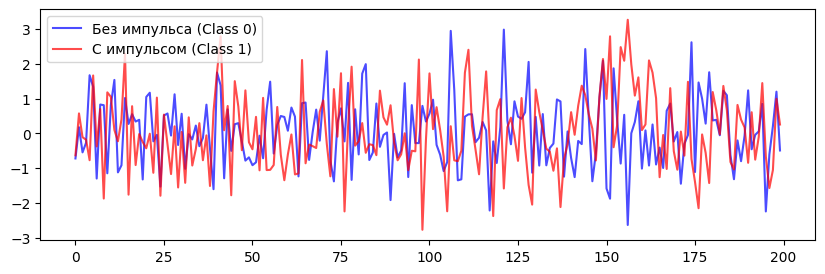

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Any

def generate_synthetic_ts_data(n_samples: int = 50, ts_length: int = 200, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X_class0 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class0 = np.zeros(n_samples // 2, dtype=int)
    X_class1 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class1 = np.ones(n_samples // 2, dtype=int)
    for i in range(n_samples // 2):
        impulse_len = np.random.randint(15, 30)
        start_idx = np.random.randint(10, ts_length - impulse_len - 10)
        x_impulse = np.linspace(-3, 3, impulse_len)
        X_class1[i, start_idx:start_idx + impulse_len] += np.exp(-0.5 * x_impulse**2) * 2
    X = np.vstack([X_class0, X_class1])
    y = np.hstack([y_class0, y_class1])
    indices = np.random.permutation(n_samples)
    return X[indices], y[indices]


X, y = generate_synthetic_ts_data(n_samples=50, ts_length=200, random_state=42)
plt.figure(figsize=(10, 3))
plt.plot(X[y == 0][0], label='Без импульса (Class 0)', color='blue', alpha=0.7)
plt.plot(X[y == 1][0], label='С импульсом (Class 1)', color='red', alpha=0.7)
plt.legend()
plt.show()

## Задание 1. Генерация кандидатов-шейплетов

**Что нужно сделать:**
Напишите функцию `generate_candidates`, которая находит все **уникальные** подпоследовательности (от `min_len` до `max_len`) из списка временных рядов.

**TODO:** Соберите кандидаты в список и верните.

In [2]:
def generate_candidates(ts_list: np.ndarray,min_len: int = 3,max_len: int = 20) -> List[np.ndarray]:
    candidates = []
    unique_candidates = set()
    for time_series in ts_list:
        for shapelet_length in range(min_len, max_len + 1):
            for start_index in range(len(time_series) - shapelet_length + 1):
                candidate = time_series[start_index:start_index + shapelet_length].copy()
                candidate_key = tuple(candidate)
                if candidate_key not in unique_candidates:
                    unique_candidates.add(candidate_key)
                    candidates.append(candidate)

    return candidates

## Задание 2. Вычисление расстояний

**Что нужно сделать:**
Разработайте функционал для поиска минимального Евклидова расстояния от шейплета до временного ряда.
Обе последовательности (сам шейплет и скользящее «окно» ряда) при сравнении должны пройти `Z-score` нормализацию.

**TODO:** Написать функции `z_normalize` и `calculate_shapelet_distance`.

In [3]:
def z_normalize(ts: np.ndarray) -> np.ndarray:
    ts = np.asarray(ts, dtype=float)
    mean_value = np.mean(ts)
    std_value = np.std(ts)
    if std_value == 0:
        z_normalized_ts = np.zeros_like(ts)
    else:
        z_normalized_ts = (ts - mean_value) / std_value

    return z_normalized_ts

def calculate_shapelet_distance(shapelet: np.ndarray,time_series: np.ndarray) -> float:
    shapelet = np.asarray(shapelet, dtype=float)
    time_series = np.asarray(time_series, dtype=float)
    shapelet_length = len(shapelet)
    if shapelet_length > len(time_series):
        raise ValueError("Длина шейплета не может превышать длину временного ряда.")
    normalized_shapelet = z_normalize(shapelet)
    distances = []
    for start_index in range(len(time_series) - shapelet_length + 1):
        window = time_series[start_index:start_index + shapelet_length]
        normalized_window = z_normalize(window)
        distance = np.sqrt(np.sum((normalized_shapelet - normalized_window) ** 2))
        distances.append(distance)
    min_dist = min(distances)
    return min_dist


In [4]:
def _entropy(y: np.ndarray) -> float:
    if len(y) == 0: return 0.0
    p = np.sum(y) / len(y)
    if p == 0 or p == 1.0: return 0.0
    return -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)

def calculate_information_gain(distances: np.ndarray, labels: np.ndarray) -> Tuple[float, float]:
    if len(distances) == 0 or len(np.unique(labels)) < 2: return 0.0, 0.0
    sorted_indices = np.argsort(distances)
    sorted_distances = distances[sorted_indices]
    sorted_labels = labels[sorted_indices]
    best_ig, best_split, initial_entropy, n = 0.0, sorted_distances[0], _entropy(labels), len(labels)
    for i in range(1, n):
        ig = initial_entropy - ((len(sorted_labels[:i])/n) * _entropy(sorted_labels[:i]) + ((n-i)/n) * _entropy(sorted_labels[i:]))
        if ig > best_ig: best_ig, best_split = ig, (sorted_distances[i-1] + sorted_distances[i]) / 2.0
    return best_ig, best_split

## Задание 3. Shapelet Transform и алгоритм классификации

**Что нужно сделать:**
Объедините все функции выше! Найдите `top_k` лучших шейплетов (по максимуму `IG`) и трансформируйте исходный датасет временных рядов `X` в матрицу признаков размерности `(n_samples, top_k)`.
Затем натренируйте Random Forest на полученных табличных данных.

**TODO:** Реализовать `shapelet_transform` и предсказать метки.

In [7]:
def shapelet_transform(X: np.ndarray,y: np.ndarray,top_k: int = 5,max_candidates: int = 10000,random_state: int = 42) -> Tuple[np.ndarray, List[Dict[str, Any]]]:
    candidates = generate_candidates(
        X,
        min_len=3,
        max_len=20
    )

    print("Всего сгенерировано кандидатов:", len(candidates))
    rng = np.random.default_rng(random_state)
    if len(candidates) > max_candidates:
        selected_indices = rng.choice(
            len(candidates),
            size=max_candidates,
            replace=False
        )

        candidates_to_check = [
            candidates[index]
            for index in selected_indices
        ]
    else:
        candidates_to_check = candidates

    print("Кандидатов для оценки:", len(candidates_to_check))
    evaluated_shapelets = []
    for number, candidate in enumerate(candidates_to_check, start=1):
        distances = np.array([
            calculate_shapelet_distance(candidate, time_series)
            for time_series in X
        ])
        ig, split = calculate_information_gain(distances,y)
        evaluated_shapelets.append({"shapelet": candidate,"ig": ig, "split": split,"distances": distances})
        if number % 100 == 0 or number == len(candidates_to_check):
            print(f"Обработано кандидатов: "f"{number}/{len(candidates_to_check)}")
    evaluated_shapelets.sort(key=lambda shapelet_info: shapelet_info["ig"],reverse=True)
    top_shapelets = evaluated_shapelets[:top_k]
    features = np.column_stack([
        shapelet_info["distances"]
        for shapelet_info in top_shapelets
    ])

    return features, top_shapelets

Всего сгенерировано кандидатов: 170550
Кандидатов для оценки: 10000
Обработано кандидатов: 100/10000
Обработано кандидатов: 200/10000
Обработано кандидатов: 300/10000
Обработано кандидатов: 400/10000
Обработано кандидатов: 500/10000
Обработано кандидатов: 600/10000
Обработано кандидатов: 700/10000
Обработано кандидатов: 800/10000
Обработано кандидатов: 900/10000
Обработано кандидатов: 1000/10000
Обработано кандидатов: 1100/10000
Обработано кандидатов: 1200/10000
Обработано кандидатов: 1300/10000
Обработано кандидатов: 1400/10000
Обработано кандидатов: 1500/10000
Обработано кандидатов: 1600/10000
Обработано кандидатов: 1700/10000
Обработано кандидатов: 1800/10000
Обработано кандидатов: 1900/10000
Обработано кандидатов: 2000/10000
Обработано кандидатов: 2100/10000
Обработано кандидатов: 2200/10000
Обработано кандидатов: 2300/10000
Обработано кандидатов: 2400/10000
Обработано кандидатов: 2500/10000
Обработано кандидатов: 2600/10000
Обработано кандидатов: 2700/10000
Обработано кандидатов: 

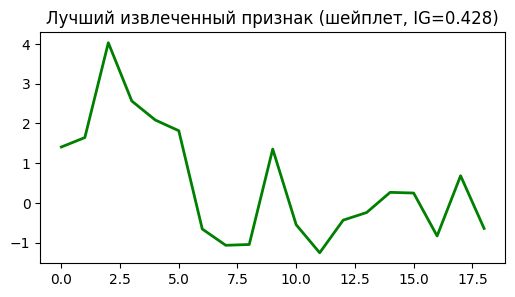

In [8]:
# Итоговое тестирование и Классификация
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

features, top_shapelets = shapelet_transform(X, y, top_k=5)
print(f"Форма новых признаков: {features.shape}")

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.3, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

best_shapelet = top_shapelets[0]['shapelet']
plt.figure(figsize=(6, 3))
plt.plot(best_shapelet, color='green', linewidth=2)
plt.title(f"Лучший извлеченный признак (шейплет, IG={top_shapelets[0]['ig']:.3f})")
plt.show()